# Difference Equations using Laplace Transforms

This notebook demonstrates solving difference equations and discrete-time systems using Laplace transforms and their connection to Z-transforms.

In [1]:
# Array-Based Laplace Transform Applications

# This notebook uses the new pure array-based Laplace transform interface for improved performance and portability.

import numpy as np
import matplotlib.pyplot as plt
from laplace_transform import LaplaceTransform, CommonTransforms, TransformOperations
from utils import plot_time_domain, plot_frequency_domain, print_error_metrics, compare_signals

# Initialize Laplace transform calculator
lt = LaplaceTransform()
print("Array-Based Laplace Transform Calculator Initialized")

Array-Based Laplace Transform Calculator Initialized


## 1. First-Order Difference Equation

**Example:** y[n] - ay[n-1] = x[n], with y[-1] = 0

This is equivalent to: y[n] = ay[n-1] + x[n]

For a = 0.5 and x[n] = u[n] (unit step)

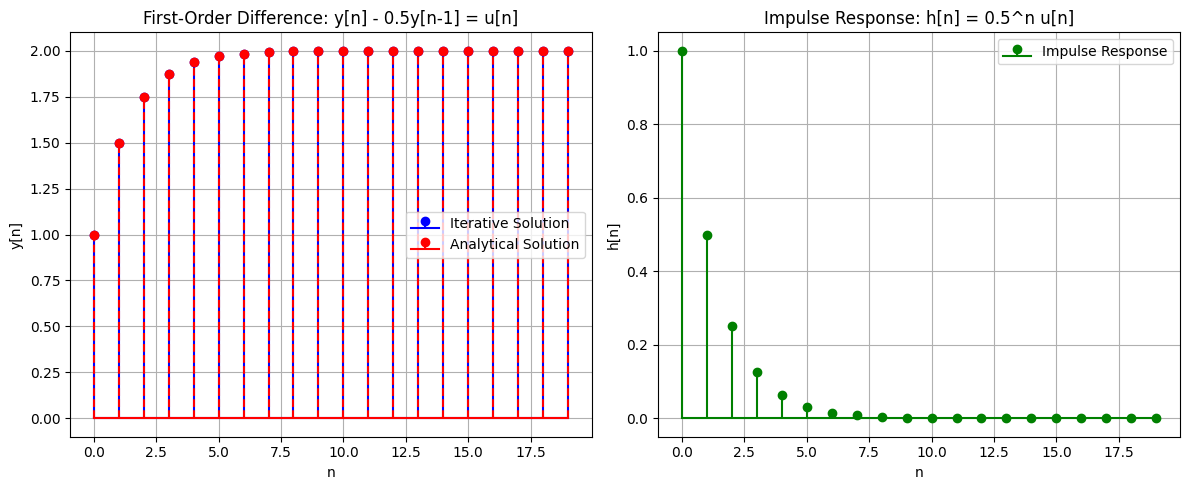

Maximum error: 0.00e+00
Steady-state value: 1.999998 (theoretical: 2.000000)


In [2]:
class FirstOrderDifference:
    """Solve first-order difference equation: y[n] - ay[n-1] = x[n]"""
    
    def __init__(self, a, y_minus1=0):
        self.a = a  # Coefficient
        self.y_minus1 = y_minus1  # Initial condition y[-1]
    
    def solve_iterative(self, x_func, n_values):
        """Solve using iterative method"""
        y = np.zeros(len(n_values))
        
        for i, n in enumerate(n_values):
            if n == 0:
                # y[0] = ay[-1] + x[0]
                y[i] = self.a * self.y_minus1 + x_func(0)
            else:
                # y[n] = ay[n-1] + x[n]
                y[i] = self.a * y[i-1] + x_func(n)
        
        return y
    
    def transfer_function(self, z):
        """Transfer function H(z) = 1/(1 - az^(-1))"""
        return 1.0 / (1 - self.a / z)
    
    def impulse_response(self, n_values):
        """Impulse response h[n] = a^n u[n]"""
        h = np.zeros(len(n_values))
        for i, n in enumerate(n_values):
            if n >= 0:
                h[i] = self.a**n
        return h
    
    def frequency_response(self, omega_values):
        """Frequency response H(e^(jω))"""
        z = np.exp(1j * omega_values)
        return self.transfer_function(z)

# Example: y[n] - 0.5y[n-1] = u[n]
a = 0.5
diff_eq = FirstOrderDifference(a)

# Define input
def unit_step_discrete(n):
    return 1.0 if n >= 0 else 0.0

# Solve
n_values = np.arange(0, 20)
y_iterative = diff_eq.solve_iterative(unit_step_discrete, n_values)

# Analytical solution: y[n] = (1 - a^(n+1))/(1 - a)
y_analytical = (1 - a**(n_values + 1)) / (1 - a)

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.stem(n_values, y_iterative, 'b-', label='Iterative Solution', basefmt='b-')
plt.stem(n_values, y_analytical, 'r--', label='Analytical Solution', basefmt='r-')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.title(f'First-Order Difference: y[n] - {a}y[n-1] = u[n]')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
h_n = diff_eq.impulse_response(n_values)
plt.stem(n_values, h_n, 'g-', label='Impulse Response', basefmt='g-')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.title(f'Impulse Response: h[n] = {a}^n u[n]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Error analysis
error = np.abs(y_iterative - y_analytical)
print(f"Maximum error: {np.max(error):.2e}")
print(f"Steady-state value: {y_analytical[-1]:.6f} (theoretical: {1/(1-a):.6f})")

## 2. Second-Order Difference Equation

**Example:** y[n] - a₁y[n-1] - a₂y[n-2] = x[n]

This represents a digital filter or discrete-time system.

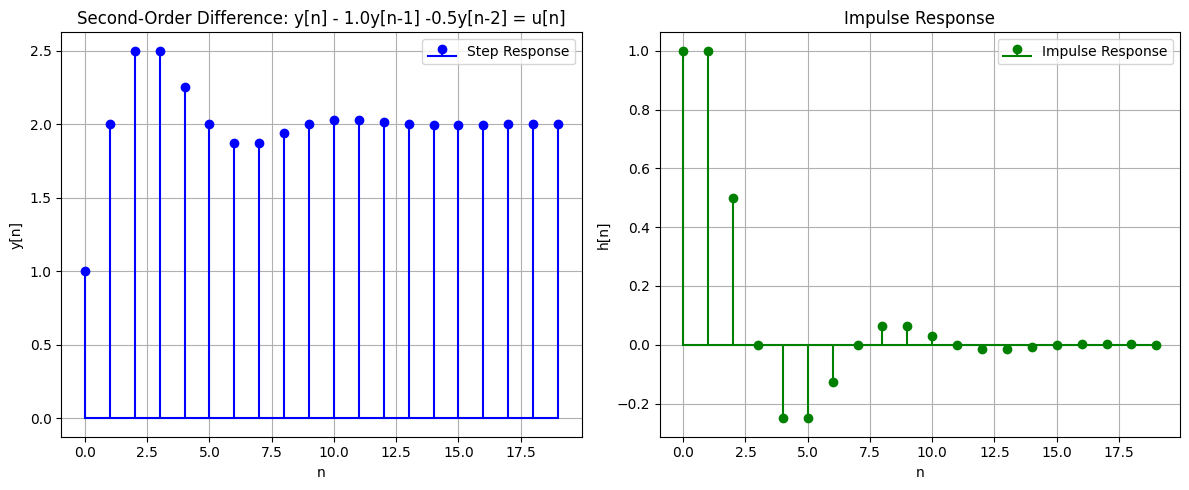

System stability: True
Steady-state value: 2.001953


In [3]:
class SecondOrderDifference:
    """Solve second-order difference equation: y[n] - a₁y[n-1] - a₂y[n-2] = x[n]"""
    
    def __init__(self, a1, a2, y_minus1=0, y_minus2=0):
        self.a1 = a1  # First coefficient
        self.a2 = a2  # Second coefficient
        self.y_minus1 = y_minus1
        self.y_minus2 = y_minus2
    
    def solve_iterative(self, x_func, n_values):
        """Solve using iterative method"""
        y = np.zeros(len(n_values))
        
        for i, n in enumerate(n_values):
            if n == 0:
                # y[0] = a₁y[-1] + a₂y[-2] + x[0]
                y[i] = self.a1 * self.y_minus1 + self.a2 * self.y_minus2 + x_func(0)
            elif n == 1:
                # y[1] = a₁y[0] + a₂y[-1] + x[1]
                y[i] = self.a1 * y[i-1] + self.a2 * self.y_minus1 + x_func(1)
            else:
                # y[n] = a₁y[n-1] + a₂y[n-2] + x[n]
                y[i] = self.a1 * y[i-1] + self.a2 * y[i-2] + x_func(n)
        
        return y
    
    def transfer_function(self, z):
        """Transfer function H(z) = 1/(1 - a₁z^(-1) - a₂z^(-2))"""
        return 1.0 / (1 - self.a1/z - self.a2/(z**2))
    
    def impulse_response(self, n_values):
        """Impulse response using iterative method"""
        def delta(n):
            return 1.0 if n == 0 else 0.0
        return self.solve_iterative(delta, n_values)
    
    def frequency_response(self, omega_values):
        """Frequency response H(e^(jω))"""
        z = np.exp(1j * omega_values)
        return self.transfer_function(z)
    
    def is_stable(self):
        """Check stability using pole locations"""
        # Characteristic equation: z² - a₁z - a₂ = 0
        # Poles: z = (a₁ ± √(a₁² + 4a₂))/2
        discriminant = self.a1**2 + 4*self.a2
        
        if discriminant >= 0:
            # Real poles
            pole1 = (self.a1 + np.sqrt(discriminant)) / 2
            pole2 = (self.a1 - np.sqrt(discriminant)) / 2
        else:
            # Complex poles
            real_part = self.a1 / 2
            imag_part = np.sqrt(-discriminant) / 2
            pole1 = complex(real_part, imag_part)
            pole2 = complex(real_part, -imag_part)
        
        # System is stable if all poles are inside unit circle
        return abs(pole1) < 1 and abs(pole2) < 1

# Example: y[n] - y[n-1] + 0.5y[n-2] = u[n]
a1 = 1.0
a2 = -0.5
diff_eq2 = SecondOrderDifference(a1, a2)

# Solve
y2_iterative = diff_eq2.solve_iterative(unit_step_discrete, n_values)

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.stem(n_values, y2_iterative, 'b-', label='Step Response', basefmt='b-')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.title(f'Second-Order Difference: y[n] - {a1}y[n-1] {a2:+.1f}y[n-2] = u[n]')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
h2_n = diff_eq2.impulse_response(n_values)
plt.stem(n_values, h2_n, 'g-', label='Impulse Response', basefmt='g-')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.title('Impulse Response')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"System stability: {diff_eq2.is_stable()}")
print(f"Steady-state value: {y2_iterative[-1]:.6f}")

## 3. Digital Filter Analysis

Analyze different types of digital filters using difference equations.

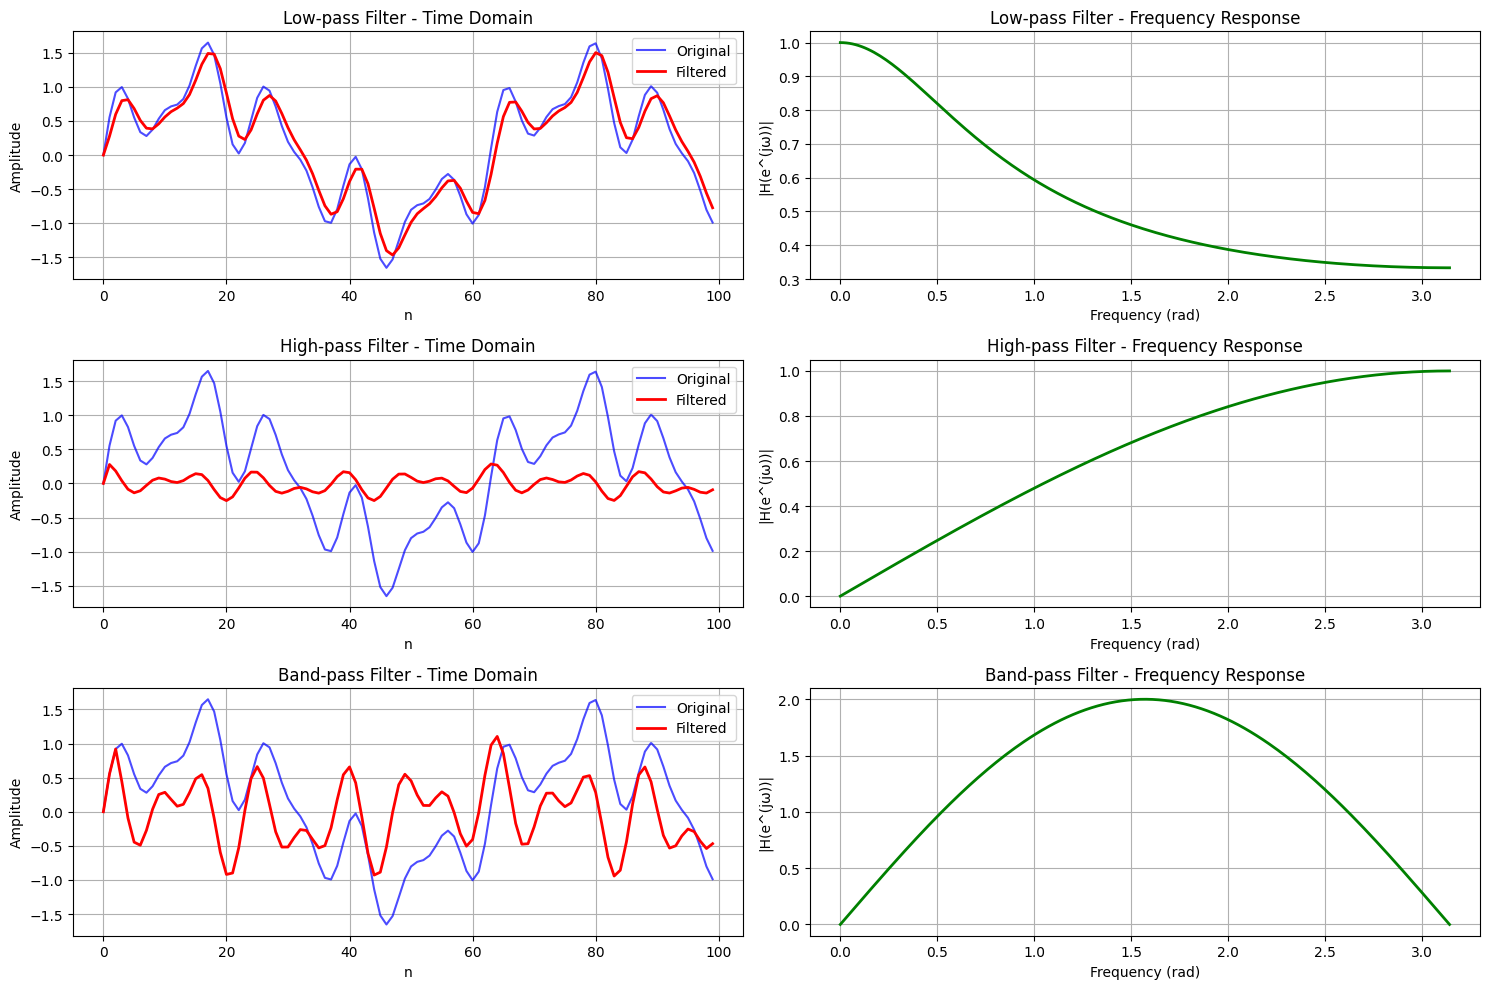

In [4]:
class DigitalFilter:
    """Digital filter implementation using difference equations"""
    
    def __init__(self, b_coeffs, a_coeffs):
        """
        b_coeffs: numerator coefficients [b₀, b₁, ..., bₘ]
        a_coeffs: denominator coefficients [a₀, a₁, ..., aₙ] (a₀ = 1)
        """
        self.b = np.array(b_coeffs)
        self.a = np.array(a_coeffs)
        self.order = len(a_coeffs) - 1
    
    def filter_signal(self, x):
        """Apply filter to input signal"""
        N = len(x)
        y = np.zeros(N)
        
        for n in range(N):
            # Input part: Σ b[k]x[n-k]
            input_sum = 0
            for k in range(len(self.b)):
                if n - k >= 0:
                    input_sum += self.b[k] * x[n - k]
            
            # Output part: Σ a[k]y[n-k]
            output_sum = 0
            for k in range(1, len(self.a)):
                if n - k >= 0:
                    output_sum += self.a[k] * y[n - k]
            
            y[n] = input_sum - output_sum
        
        return y
    
    def frequency_response(self, omega_values):
        """Frequency response H(e^(jω))"""
        H = np.zeros(len(omega_values), dtype=complex)
        
        for i, omega in enumerate(omega_values):
            z = np.exp(1j * omega)
            
            # Numerator: Σ b[k]z^(-k)
            numerator = 0
            for k in range(len(self.b)):
                numerator += self.b[k] * z**(-k)
            
            # Denominator: Σ a[k]z^(-k)
            denominator = 0
            for k in range(len(self.a)):
                denominator += self.a[k] * z**(-k)
            
            H[i] = numerator / denominator
        
        return H

# Create different filters

# Low-pass filter: y[n] = 0.5y[n-1] + 0.5x[n]
lowpass = DigitalFilter([0.5], [1, -0.5])

# High-pass filter: y[n] = 0.5x[n] - 0.5x[n-1]
highpass = DigitalFilter([0.5, -0.5], [1])

# Band-pass filter: y[n] = x[n] - x[n-2]
bandpass = DigitalFilter([1, 0, -1], [1])

filters = {
    'Low-pass': lowpass,
    'High-pass': highpass,
    'Band-pass': bandpass
}

# Test signal: combination of different frequencies
n_test = np.arange(0, 100)
test_signal = np.sin(0.1 * n_test) + 0.5 * np.sin(0.5 * n_test) + 0.3 * np.sin(0.8 * n_test)

# Apply filters
plt.figure(figsize=(15, 10))

for i, (name, filt) in enumerate(filters.items()):
    filtered_signal = filt.filter_signal(test_signal)
    
    plt.subplot(3, 2, 2*i + 1)
    plt.plot(n_test, test_signal, 'b-', alpha=0.7, label='Original')
    plt.plot(n_test, filtered_signal, 'r-', linewidth=2, label='Filtered')
    plt.xlabel('n')
    plt.ylabel('Amplitude')
    plt.title(f'{name} Filter - Time Domain')
    plt.legend()
    plt.grid(True)
    
    # Frequency response
    omega = np.linspace(0, np.pi, 200)
    H = filt.frequency_response(omega)
    
    plt.subplot(3, 2, 2*i + 2)
    plt.plot(omega, np.abs(H), 'g-', linewidth=2)
    plt.xlabel('Frequency (rad)')
    plt.ylabel('|H(e^(jω))|')
    plt.title(f'{name} Filter - Frequency Response')
    plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Convolution in Discrete Time

Demonstrate convolution using difference equations and compare with direct convolution.

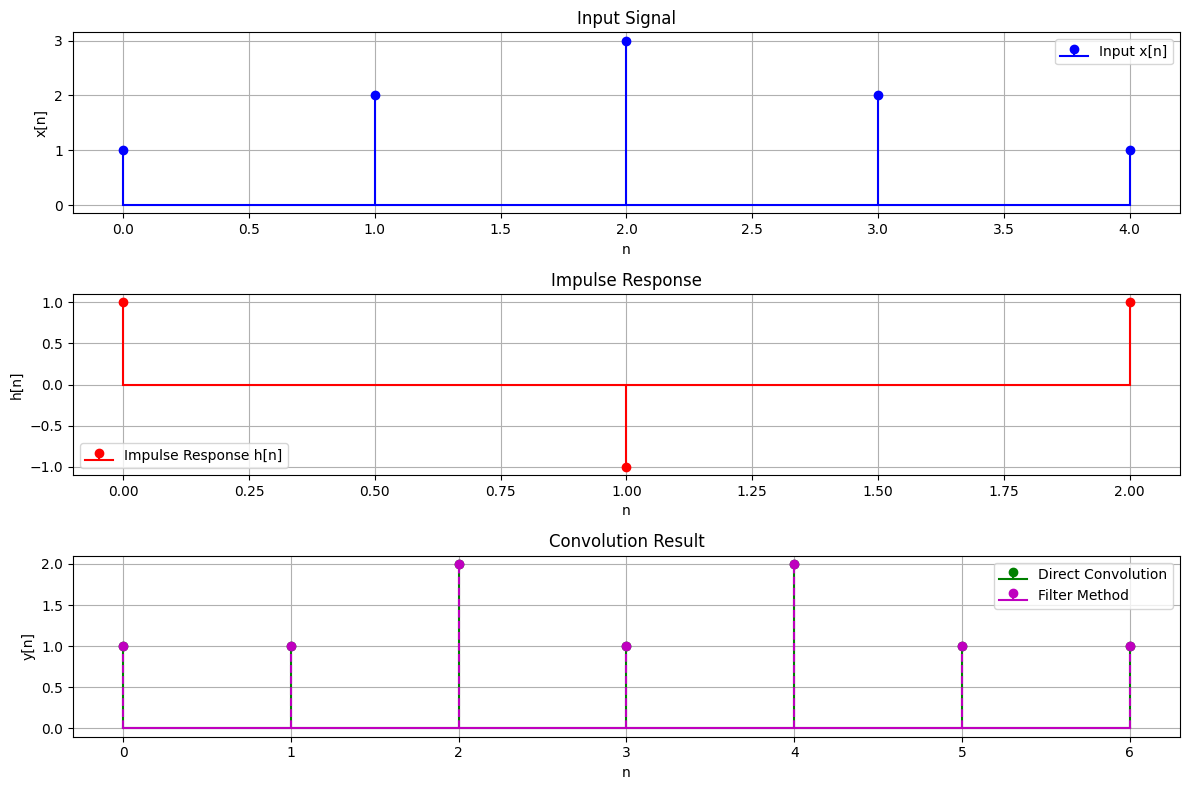

Maximum difference between methods: 0.00e+00
Convolution result: [1. 1. 2. 1. 2. 1. 1.]


In [5]:
def discrete_convolution(x, h):
    """Discrete convolution y[n] = Σ x[k]h[n-k]"""
    N = len(x) + len(h) - 1
    y = np.zeros(N)
    
    for n in range(N):
        for k in range(len(x)):
            if 0 <= n - k < len(h):
                y[n] += x[k] * h[n - k]
    
    return y

# Test signals
x_signal = np.array([1, 2, 3, 2, 1])  # Input signal
h_signal = np.array([1, -1, 1])      # Impulse response

# Direct convolution
y_direct = discrete_convolution(x_signal, h_signal)

# Using difference equation (filter)
conv_filter = DigitalFilter(h_signal, [1])
y_filter = conv_filter.filter_signal(np.concatenate([x_signal, np.zeros(len(h_signal)-1)]))
y_filter = y_filter[:len(y_direct)]  # Trim to same length

# Plot results
n_conv = np.arange(len(y_direct))

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.stem(np.arange(len(x_signal)), x_signal, 'b-', label='Input x[n]', basefmt='b-')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.title('Input Signal')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(np.arange(len(h_signal)), h_signal, 'r-', label='Impulse Response h[n]', basefmt='r-')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.title('Impulse Response')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.stem(n_conv, y_direct, 'g-', label='Direct Convolution', basefmt='g-')
plt.stem(n_conv, y_filter, 'm--', label='Filter Method', basefmt='m-')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.title('Convolution Result')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Verify results
error = np.abs(y_direct - y_filter)
print(f"Maximum difference between methods: {np.max(error):.2e}")
print(f"Convolution result: {y_direct}")

## 5. Stability Analysis of Discrete Systems

Analyze stability based on pole locations in the z-plane.


Stable System:
  Poles: [np.float64(0.76234753829798), np.float64(-0.26234753829797997)] (Real)
  Pole magnitudes: [np.float64(0.76234753829798), np.float64(0.26234753829797997)]
  Stable: True

Marginally Stable System:
  Poles: [(0.5+0.8660254037844386j), (0.5-0.8660254037844386j)] (Complex)
  Pole magnitudes: [0.9999999999999999, 0.9999999999999999]
  Stable: True

Unstable System:
  Poles: [np.float64(1.7807764064044151), np.float64(-0.28077640640441515)] (Real)
  Pole magnitudes: [np.float64(1.7807764064044151), np.float64(0.28077640640441515)]
  Stable: False


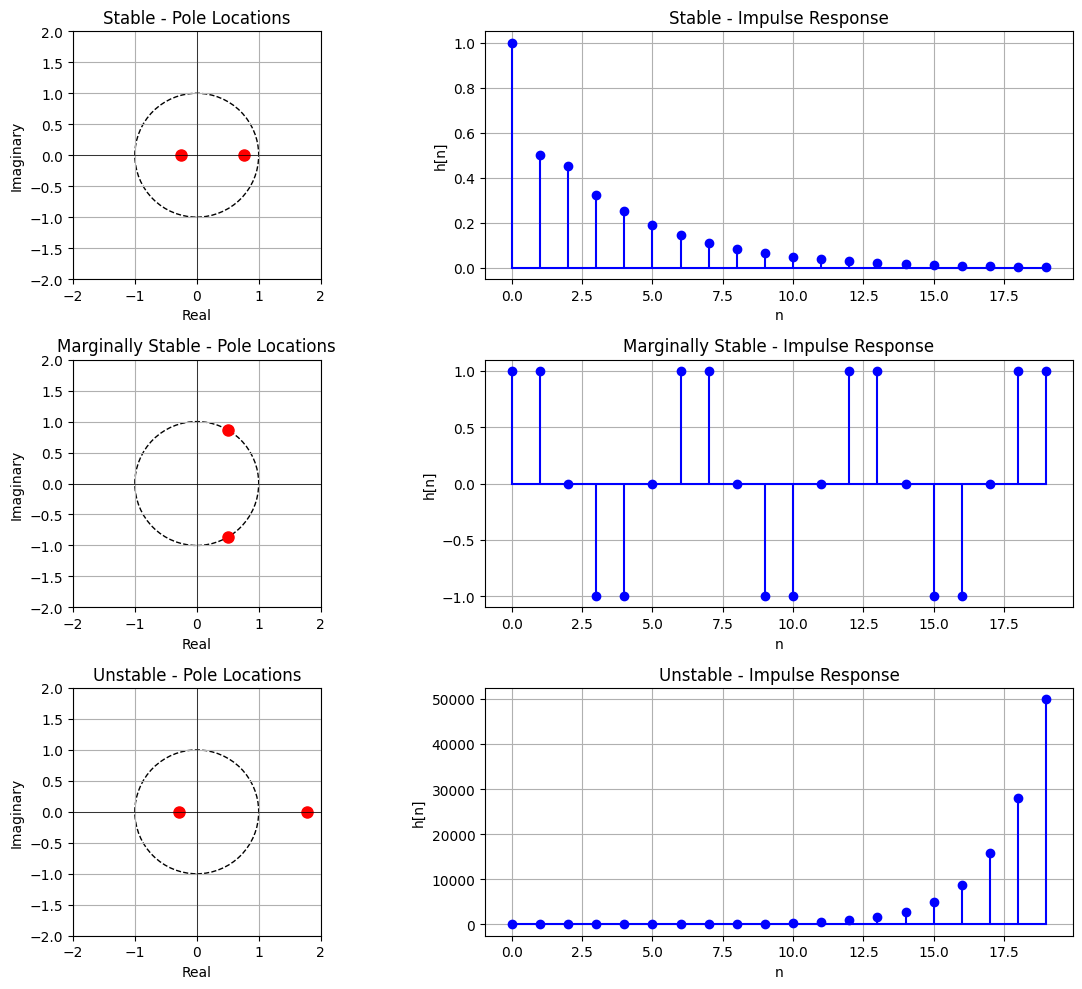


DISCRETE SYSTEM STABILITY CRITERION
System is stable if all poles are inside the unit circle (|z| < 1)
This corresponds to bounded impulse response.


In [6]:
# Create systems with different stability characteristics
systems_stability = {
    'Stable': SecondOrderDifference(0.5, 0.2),
    'Marginally Stable': SecondOrderDifference(1.0, -1.0),
    'Unstable': SecondOrderDifference(1.5, 0.5)
}

# Analyze pole locations
def analyze_poles_discrete(system):
    """Analyze pole locations for discrete system"""
    a1, a2 = system.a1, system.a2
    
    # Characteristic equation: z² - a₁z - a₂ = 0
    discriminant = a1**2 + 4*a2
    
    if discriminant >= 0:
        pole1 = (a1 + np.sqrt(discriminant)) / 2
        pole2 = (a1 - np.sqrt(discriminant)) / 2
        pole_type = "Real"
    else:
        real_part = a1 / 2
        imag_part = np.sqrt(-discriminant) / 2
        pole1 = complex(real_part, imag_part)
        pole2 = complex(real_part, -imag_part)
        pole_type = "Complex"
    
    return [pole1, pole2], pole_type

# Plot pole locations and impulse responses
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for i, (name, system) in enumerate(systems_stability.items()):
    poles, pole_type = analyze_poles_discrete(system)
    
    # Pole-zero plot
    ax_poles = axes[i, 0]
    circle = plt.Circle((0, 0), 1, fill=False, color='k', linestyle='--')
    ax_poles.add_patch(circle)
    
    for pole in poles:
        ax_poles.plot(pole.real, pole.imag, 'ro', markersize=8)
    
    ax_poles.axhline(y=0, color='k', linewidth=0.5)
    ax_poles.axvline(x=0, color='k', linewidth=0.5)
    ax_poles.set_xlim(-2, 2)
    ax_poles.set_ylim(-2, 2)
    ax_poles.set_xlabel('Real')
    ax_poles.set_ylabel('Imaginary')
    ax_poles.set_title(f'{name} - Pole Locations')
    ax_poles.set_aspect('equal')
    ax_poles.grid(True)
    
    # Impulse response
    ax_impulse = axes[i, 1]
    h_n = system.impulse_response(n_values[:20])
    ax_impulse.stem(n_values[:20], h_n, 'b-', basefmt='b-')
    ax_impulse.set_xlabel('n')
    ax_impulse.set_ylabel('h[n]')
    ax_impulse.set_title(f'{name} - Impulse Response')
    ax_impulse.grid(True)
    
    print(f"\n{name} System:")
    print(f"  Poles: {poles} ({pole_type})")
    print(f"  Pole magnitudes: {[abs(p) for p in poles]}")
    print(f"  Stable: {system.is_stable()}")

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("DISCRETE SYSTEM STABILITY CRITERION")
print("="*50)
print("System is stable if all poles are inside the unit circle (|z| < 1)")
print("This corresponds to bounded impulse response.")

## 6. Summary

This notebook demonstrated solving difference equations and discrete-time systems:

1. **First-Order Difference Equations**: Solved y[n] - ay[n-1] = x[n] with iterative methods
2. **Second-Order Difference Equations**: Handled higher-order discrete systems
3. **Digital Filters**: Implemented low-pass, high-pass, and band-pass filters
4. **Discrete Convolution**: Compared direct convolution with filter-based methods
5. **Stability Analysis**: Analyzed pole locations in the z-plane

Key insights:
- Difference equations are the discrete-time equivalent of differential equations
- Z-transform is the natural tool for discrete-time analysis (related to Laplace transform)
- Digital filters are implemented using difference equations
- Stability requires poles inside the unit circle in the z-plane
- Convolution in discrete time follows the same principles as continuous time

The connection between Laplace transforms and Z-transforms provides a unified framework for analyzing both continuous and discrete-time systems.